# Muestra de archivo Markdown

## Formatos en markdown 

### Formato de texto

Normal

**Negritas**

*Cursivas*

~~Tachado~~

> Cita ó resaltado

#### Colores con html

<p style="color:red"> Texto en rojo </p>
<b>
<p style="color:red"> Texto en rojo y negritas </p>
</b>

#### Hipervínculos

[Google](https://www.google.com/)

[Github](https://www.github.com/)

### Listas

#### Lista ordenada
1. Primer elemento
2. Segundo elemento
3. Tercer elemento

#### Lista sin orden

- Algo
- Otra cosa
- Algo más

#### lista con checkbox

- [🇧🇷] Algo
- [✔︎] Otra cosa
- [✖︎] Algo más 

### Tablas

#### Tabla sencilla

|Titulo 1🕶️| Titulo 2 🕶️ | Titulo 3🕶️|
|--------|-----------|---------|
|Elem 1a  |Elem 2a     | Elem 3a  |
|Elem 1b  |Elem 2b     | Elem 3b  |

---

#### Tabla alineada

|Izquierda 🕶️| Centro 🕶️ | Derecha 🕶️|
|:-----------|:---------:|----------:|
|Elem 1a     |Elem 2a    | Elem 3a   |
|Elem 1b     |Elem 2b    | Elem 3b   |


### Imágenes

#### Importada con html
- <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTfVMOHz15Psr7yzp-DKtKsD5d8sVhRg4mxnA&s" height=60/>
- <img src="https://www.modlearth.com/assets/posts/2024/20241207/portada/2024-12-08-dji-ubuntu-24.04.webp" height=60/>
- <img src="imagen.jpg" height=60/>


### Ecuaciones con LaTEX

 $ y=x^2 $

 $ y = \frac{1}{x} $

 $ {}^{0} {T}_{1} $

 


### Bloques de código

---
Código de python

~~~python
#Código de python
def funcion():
  pass
~~~

---
Código de bash

~~~bash
echo "Mensaje"
cd ~/
mkdir Dev
echo "Creada carpeta Dev"
~~~

## Código con python

In [52]:
x = 10
y = 15
z = "a"

In [53]:
print(x)

10


### Uso de sympy

In [54]:
import sympy
from sympy import *

In [55]:
variable = Symbol("a")
segunda_variable = Symbol("b")
tercera_variable = Symbol('theta')
eq = variable + segunda_variable
print(eq)
#Ecuación de tiempo
t = Symbol("t")
eq2 = t**2 + 2*t + 1
eq2_deriv = diff(eq2, t)
print(eq2)
print(eq2_deriv)
v4 = cos(t)
v5 = sin(t)
eq3 = simplify(v4**2 + v5**2)
print(eq3)

a + b
t**2 + 2*t + 1
2*t + 2
1


In [56]:
A = Matrix([[1,2], [3,4]])
B = Matrix([[1, 0], [0, 1]])
C = Matrix([[1, 1], [1, 1]])
print(A * B + 5*C)

Matrix([[6, 7], [8, 9]])


In [57]:
A = Matrix([[t,2 + t], [t**2,t]])
print(A)
print(diff(A, t))
det_A = det(A)
print(det_A)


Matrix([[t, t + 2], [t**2, t]])
Matrix([[1, 1], [2*t, 1]])
-t**3 - t**2


In [58]:
#Ecuación como una función
def func(a):
  eq = Matrix([[a, 0], [0,a]])
  return eq
print(func(t+1))

Matrix([[t + 1, 0], [0, t + 1]])


In [59]:
#Matrices de rotación
def r_z(alpha):
  rz = Matrix([[cos(alpha), -sin(alpha), 0], 
               [sin(alpha),  cos(alpha), 0], 
               [0         ,           0, 1]])
  return rz

In [60]:
th1, th2, th3 = symbols("theta_1, theta_2, theta_3")
r_z(th3)

Matrix([
[cos(theta_3), -sin(theta_3), 0],
[sin(theta_3),  cos(theta_3), 0],
[           0,             0, 1]])

In [61]:
#para un manipulador de 3GDL en el plano XY
th1, th2, th3 = symbols("theta_1, theta_2, theta_3")
l1, l2, l3 = symbols("l_1, l_2, l_3")
p_0_1 = Matrix([[0],[0],[0]])
p_1_2 = Matrix([[l1],[0],[0]])
p_2_3 = Matrix([[l2],[0],[0]])
p_3_p = Matrix([[l3],[0],[0]])
R_0_1 = r_z(th1)
R_1_2 = r_z(th2)
R_2_3 = r_z(th3)
R_3_p = r_z(0)

In [62]:
def tr_h(rot, pos):
  a = Matrix.vstack(rot, Matrix([[0,0,0]]))
  b = Matrix.vstack(pos, Matrix([1]))
  t_h = Matrix.hstack(a, b)
  return t_h


In [63]:
T_0_1 = tr_h(R_0_1, p_0_1)
T_1_2 = tr_h(R_1_2, p_1_2)
T_2_3 = tr_h(R_2_3, p_2_3)
T_3_p = tr_h(R_3_p, p_3_p)
T_0_p = T_0_1 * T_1_2 * T_2_3 * T_3_p
T_0_p = simplify(T_0_p)


In [64]:
simplify(T_0_p)

Matrix([
[cos(theta_1 + theta_2 + theta_3), -sin(theta_1 + theta_2 + theta_3), 0, l_1*cos(theta_1) + l_2*cos(theta_1 + theta_2) + l_3*cos(theta_1 + theta_2 + theta_3)],
[sin(theta_1 + theta_2 + theta_3),  cos(theta_1 + theta_2 + theta_3), 0, l_1*sin(theta_1) + l_2*sin(theta_1 + theta_2) + l_3*sin(theta_1 + theta_2 + theta_3)],
[                               0,                                 0, 1,                                                                                    0],
[                               0,                                 0, 0,                                                                                    1]])

In [65]:
xi = Matrix([T_0_p[0, 3],
             T_0_p[1, 3],
             atan2(T_0_p[1, 0], T_0_p[0,0])])
xi = xi.subs({l1: 0.1, l2: 0.1, l3: 0.1})
simplify(xi)

Matrix([
[0.1*cos(theta_1) + 0.1*cos(theta_1 + theta_2) + 0.1*cos(theta_1 + theta_2 + theta_3)],
[0.1*sin(theta_1) + 0.1*sin(theta_1 + theta_2) + 0.1*sin(theta_1 + theta_2 + theta_3)],
[           atan2(sin(theta_1 + theta_2 + theta_3), cos(theta_1 + theta_2 + theta_3))]])

In [66]:
xi.subs({th1: 0, th2: 0, th3: 0})

Matrix([
[0.3],
[  0],
[  0]])

In [67]:
J = Matrix([[diff(xi, th1), 
             diff(xi, th2), 
             diff(xi, th3)]])
J = simplify(J)
J_inv = simplify(J.inverse())
J_inv

Matrix([
[                       10.0*cos(theta_1 + theta_2)/sin(theta_2),                        10.0*sin(theta_1 + theta_2)/sin(theta_2),                                 1.0*sin(theta_3)/sin(theta_2)],
[-(10.0*cos(theta_1) + 10.0*cos(theta_1 + theta_2))/sin(theta_2), -(10.0*sin(theta_1) + 10.0*sin(theta_1 + theta_2))/sin(theta_2), -(1.0*sin(theta_3) + 1.0*sin(theta_2 + theta_3))/sin(theta_2)],
[                                 10.0*cos(theta_1)/sin(theta_2),                                  10.0*sin(theta_1)/sin(theta_2),        1.0*sin(theta_3)/tan(theta_2) + 1.0*cos(theta_3) + 1.0]])

In [68]:
# Variables de velocidad de juntas y efector final
th1_dot, th2_dot, th3_dot = symbols("th1_dot, th2_dot, th3_dot")
x_dot, y_dot, alpha_dot = symbols("x_dot, y_dot, alpha_dot")


In [69]:
# Velocidades del efector final
xi_dot = Matrix([x_dot, y_dot, alpha_dot])
xi_dot

Matrix([
[    x_dot],
[    y_dot],
[alpha_dot]])

In [70]:
th_dot = J_inv * xi_dot
th_dot

Matrix([
[                                                                            1.0*alpha_dot*sin(theta_3)/sin(theta_2) + 10.0*x_dot*cos(theta_1 + theta_2)/sin(theta_2) + 10.0*y_dot*sin(theta_1 + theta_2)/sin(theta_2)],
[-alpha_dot*(1.0*sin(theta_3) + 1.0*sin(theta_2 + theta_3))/sin(theta_2) - x_dot*(10.0*cos(theta_1) + 10.0*cos(theta_1 + theta_2))/sin(theta_2) - y_dot*(10.0*sin(theta_1) + 10.0*sin(theta_1 + theta_2))/sin(theta_2)],
[                                                                     alpha_dot*(1.0*sin(theta_3)/tan(theta_2) + 1.0*cos(theta_3) + 1.0) + 10.0*x_dot*cos(theta_1)/sin(theta_2) + 10.0*y_dot*sin(theta_1)/sin(theta_2)]])

In [71]:
th_dot = th_dot.subs({l1: 0.1, l2: 0.1, l3: 0.1})
th_dot.subs({th1: pi/4,
             th2: pi/4,
             th3: pi/4,
             x_dot: 0.1,
             y_dot: -0.1,
             alpha_dot: 0})

Matrix([
[                           -1.0*sqrt(2)],
[-1.0 + 0.1*sqrt(2)*(5.0*sqrt(2) + 10.0)],
[                                      0]])

In [72]:
# Construir una trayectoria
a_0, a_1, a_2, a_3, a_4, a_5 = symbols("a_0, a_1, a_2, a_3, a_4, a_5")
lam = a_0 + a_1 * t + a_2 * t**2 + a_3 * t**3 + a_4 * t**4 + a_5 * t**5
lam

a_0 + a_1*t + a_2*t**2 + a_3*t**3 + a_4*t**4 + a_5*t**5

In [73]:
# derivadas del polinomio
lam_dot = diff(lam, t)
lam_dot_dot = diff(lam_dot, t)

In [74]:
tf = 2
# Posiciones iniciales de las juntas y efector final
# Posicion inicial de las juntas (rad)
th1_in = 0.1
th2_in = 0.1
th3_in = 0.1
# Posición del efector final substituyendo en la postura (m, rad)
x_in = xi[0].subs({th1: th1_in, th2: th2_in, th3: th3_in})
y_in = xi[1].subs({th1: th1_in, th2: th2_in, th3: th3_in})
alpha_in = xi[2].subs({th1: th1_in, th2: th2_in, th3: th3_in})
# Posición final deseada (m, rad)
x_f = 0.2
y_f = 0.1
alpha_f = pi/12
eq1 = lam.subs({t: 0})
eq2 = lam.subs({t: tf}) - 1
eq3 = lam_dot.subs({t: 0})
eq4 = lam_dot.subs({t: tf})
eq5 = lam_dot_dot.subs({t: 0})
eq6 = lam_dot_dot.subs({t: tf})

In [75]:
solutions = solve((eq1, eq2, eq3, eq4, eq5, eq6),
                  (a_0, a_1, a_2, a_3, a_4, a_5))
solutions

{a_0: 0, a_1: 0, a_2: 0, a_3: 5/4, a_4: -15/16, a_5: 3/16}

In [76]:
lam_s = lam.subs(solutions)

In [77]:
# Posición, velocidad y aceleración en x
x_eq = x_in + lam_s * (x_f - x_in)
x_dot_eq = diff(x_eq, t)
x_dot_dot_eq = diff(x_dot_eq, t)

In [78]:
# Posición, velocidad y aceleración en y
y_eq = y_in + lam_s * (y_f - y_in)
y_dot_eq = diff(y_eq, t)
y_dot_dot_eq = diff(y_dot_eq, t)

In [79]:
# Posición, velocidad y aceleración en alpha
alpha_eq = alpha_in + lam_s * (alpha_f - alpha_in)
alpha_dot_eq = diff(alpha_eq, t)
alpha_dot_dot_eq = diff(alpha_dot_eq, t)

In [80]:
#Para un manipulador de 3 GDL en el plano XY
th1_dot, th2_dot, th3_dot = symbols("th1_dot, th2_dot, th3_dot")
#th_dot = Matrix([th1_dot, th2_dot, th3_dot])
xi_dot = J * th_dot
xi_dot

Matrix([
[(-0.1*sin(theta_1 + theta_2) - 0.1*sin(theta_1 + theta_2 + theta_3))*(-alpha_dot*(1.0*sin(theta_3) + 1.0*sin(theta_2 + theta_3))/sin(theta_2) - x_dot*(10.0*cos(theta_1) + 10.0*cos(theta_1 + theta_2))/sin(theta_2) - y_dot*(10.0*sin(theta_1) + 10.0*sin(theta_1 + theta_2))/sin(theta_2)) - 0.1*(alpha_dot*(1.0*sin(theta_3)/tan(theta_2) + 1.0*cos(theta_3) + 1.0) + 10.0*x_dot*cos(theta_1)/sin(theta_2) + 10.0*y_dot*sin(theta_1)/sin(theta_2))*sin(theta_1 + theta_2 + theta_3) + (1.0*alpha_dot*sin(theta_3)/sin(theta_2) + 10.0*x_dot*cos(theta_1 + theta_2)/sin(theta_2) + 10.0*y_dot*sin(theta_1 + theta_2)/sin(theta_2))*(-0.1*sin(theta_1) - 0.1*sin(theta_1 + theta_2) - 0.1*sin(theta_1 + theta_2 + theta_3))],
[  (0.1*cos(theta_1 + theta_2) + 0.1*cos(theta_1 + theta_2 + theta_3))*(-alpha_dot*(1.0*sin(theta_3) + 1.0*sin(theta_2 + theta_3))/sin(theta_2) - x_dot*(10.0*cos(theta_1) + 10.0*cos(theta_1 + theta_2))/sin(theta_2) - y_dot*(10.0*sin(theta_1) + 10.0*sin(theta_1 + theta_2))/sin(theta_2)) 

In [81]:
# Graficar posiciones del efector final
import matplotlib
import matplotlib.pyplot as plt
# Para manejarlo de forma discreta, muestreamos
frec = 60
dt = 1.0/frec
dt
samples = int(frec*tf) + 1
samples

121

In [82]:
# Generar arreglos para guardar muestreo
t_m = Matrix.zeros(1, samples)
for i in range(samples):
  t_m[i] = dt * i
t_m

Matrix([[0, 0.0166666666666667, 0.0333333333333333, 0.05, 0.0666666666666667, 0.0833333333333333, 0.1, 0.116666666666667, 0.133333333333333, 0.15, 0.166666666666667, 0.183333333333333, 0.2, 0.216666666666667, 0.233333333333333, 0.25, 0.266666666666667, 0.283333333333333, 0.3, 0.316666666666667, 0.333333333333333, 0.35, 0.366666666666667, 0.383333333333333, 0.4, 0.416666666666667, 0.433333333333333, 0.45, 0.466666666666667, 0.483333333333333, 0.5, 0.516666666666667, 0.533333333333333, 0.55, 0.566666666666667, 0.583333333333333, 0.6, 0.616666666666667, 0.633333333333333, 0.65, 0.666666666666667, 0.683333333333333, 0.7, 0.716666666666667, 0.733333333333333, 0.75, 0.766666666666667, 0.783333333333333, 0.8, 0.816666666666667, 0.833333333333333, 0.85, 0.866666666666667, 0.883333333333333, 0.9, 0.916666666666667, 0.933333333333333, 0.95, 0.966666666666667, 0.983333333333333, 1.0, 1.01666666666667, 1.03333333333333, 1.05, 1.06666666666667, 1.08333333333333, 1.1, 1.11666666666667, 1.13333333333

In [83]:
# Arreglos para posición, velocidad y aceleración
xi_m         = Matrix.zeros(3, samples)
xi_dot_m     = Matrix.zeros(3, samples)
xi_dot_dot_m = Matrix.zeros(3, samples)
xi_m

Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [84]:
xi_t = Matrix([x_eq, y_eq, alpha_eq])
xi_dot_t = Matrix([x_dot_eq, y_dot_eq, alpha_dot_eq])
xi_dot_dot_t = Matrix([x_dot_dot_eq, y_dot_dot_eq, alpha_dot_dot_eq])
xi_t

Matrix([
[  -0.0174451356045914*t**5 + 0.0872256780229569*t**4 - 0.116300904030609*t**3 + 0.293040723224487],
[0.00761206961056446*t**5 - 0.0380603480528223*t**4 + 0.0507471307370964*t**3 + 0.0594022954103229],
[                                         (-0.3 + pi/12)*(3*t**5/16 - 15*t**4/16 + 5*t**3/4) + 0.3]])

In [85]:
# Muestreo
for i in range(samples):
  xi_m[:, i]         = xi_t.        subs({t: t_m[i]})
  xi_dot_m[:, i]     = xi_dot_t.    subs({t: t_m[i]})
  xi_dot_dot_m[:, i] = xi_dot_dot_t.subs({t: t_m[i]})
xi_m

Matrix([
[ 0.293040723224487,                         0.293040191502318,                         0.293036522751713,                          0.293026725320366,                         0.293007963700705,                          0.292977555837738,                     0.292932970436903,                           0.292871824271922,                          0.292791879492644,                         0.292691040932898,                           0.292567353418344,                          0.292418999074319,                  0.292244294633686,                           0.292041688744688,                          0.291809759278793,                          0.291547210638547,                           0.29125287106542,                          0.290925689947657,               0.290564735128128,                          0.290169190212176,                           0.28973835187547,                          0.289271627171849,                          0.288768530841175,                          0.

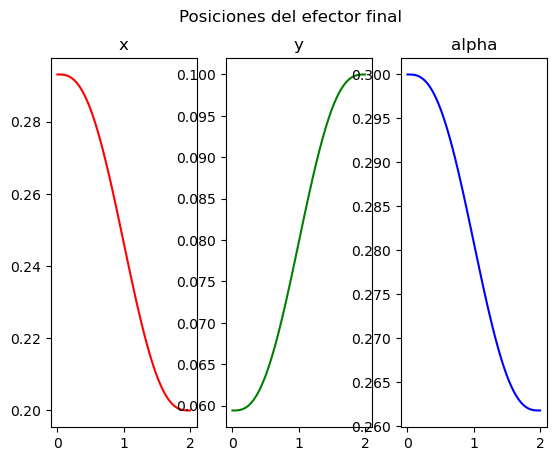

In [86]:
# Gráficas
fig, (x_g, y_g, al_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Posiciones del efector final")
x_g.set_title("x")
y_g.set_title("y")
al_g.set_title("alpha")
x_g.plot(t_m.T, xi_m[0, :].T, color="RED")
y_g.plot(t_m.T, xi_m[1, :].T, color="green")
al_g.plot(t_m.T, xi_m[2, :].T, color=(0,0,1))
plt.show()

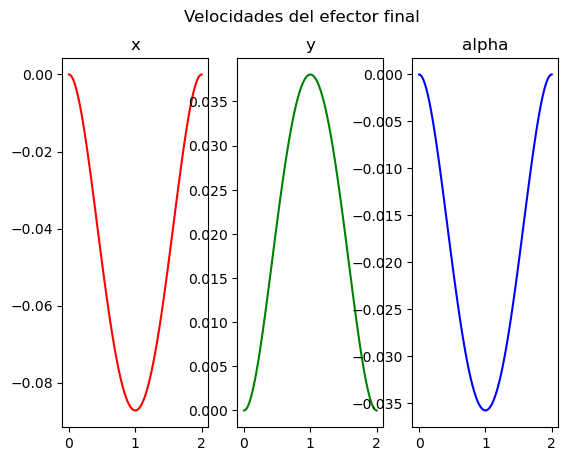

In [87]:
fig, (x_g, y_g, al_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Velocidades del efector final")
x_g.set_title("x")
y_g.set_title("y")
al_g.set_title("alpha")
x_g.plot(t_m.T, xi_dot_m[0, :].T, color="RED")
y_g.plot(t_m.T, xi_dot_m[1, :].T, color="green")
al_g.plot(t_m.T, xi_dot_m[2, :].T, color=(0,0,1))
plt.show()

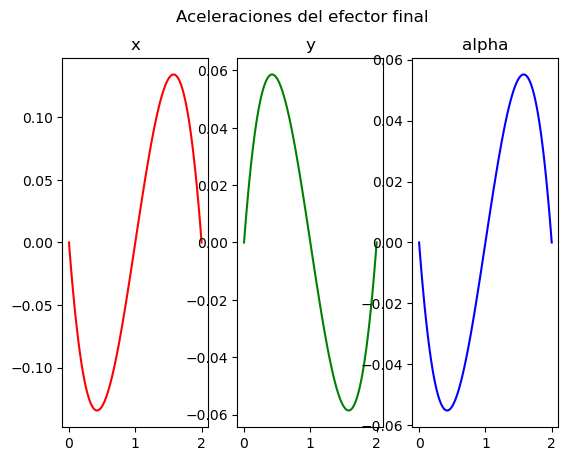

In [88]:
fig, (x_g, y_g, al_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Aceleraciones del efector final")
x_g.set_title("x")
y_g.set_title("y")
al_g.set_title("alpha")
x_g.plot(t_m.T, xi_dot_dot_m[0, :].T, color="RED")
y_g.plot(t_m.T, xi_dot_dot_m[1, :].T, color="green")
al_g.plot(t_m.T, xi_dot_dot_m[2, :].T, color=(0,0,1))
plt.show()

In [93]:
#Arreglos para posición y velocidad de las juntas
th_m = Matrix.zeros(3, samples)
th_dot_m = Matrix.zeros(3, samples)
th_dot_dot_m = Matrix.zeros(3, samples)
th_m[:, 0] = Matrix([th1_in, th2_in, th3_in])
# Cinemática inversa
for i in range(samples):
  th_dot_m[:, i] = (th_dot.subs({th1: th_m[0, i], th2: th_m[1, i], 
                                th3: th_m[2, i], x_dot: xi_dot_m[0, i],
                                y_dot: xi_dot_m[1, i], 
                                alpha_dot: xi_dot_m[2, i]})).evalf()
  print(i)
  if i < samples - 1:
    th_m[:, i+1] = th_m[:, i] + th_dot_m[:, i] * dt
  if i > 0:
    th_dot_dot_m[:, i-1] = (th_dot_m[:, i] - th_dot_m[:, i-1])/dt
th_dot_dot_m

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120


Matrix([
[-0.514081710062426, -1.50166436959508, -2.39041826974809, -3.09938314285506, -3.54399757538257, -3.68467165779414, -3.55354646176205, -3.23731161449373, -2.83381965896048, -2.41805651692412, -2.03259526703431, -1.69437699286714, -1.40535102272924, -1.16064846774693, -0.953286960398478, -0.776385238378818, -0.623991105077892, -0.491253265321974, -0.374329106761335, -0.270213102761654, -0.176562933106157, -0.0915501144849751, -0.0137404889646908,  0.057998127408212,  0.124566092352008,  0.186684820268905,  0.244936575999422,  0.299794467920858,  0.351645140135468,  0.400806029641674,  0.447538569144539,  0.492058353975837,    0.53454302479206,   0.57513842239036,  0.613963428263946,  0.651113800155154,  0.686665235366304,  0.720675838311888,  0.753188127220299,  0.784230684033276,   0.81381952853243,   0.84195928046045,  0.868644160388867,  0.893858870207832,  0.917579386568198,  0.939773694785878,  0.960402486178383,  0.979419838204387,  0.996773893861574,    1.01240755436919,

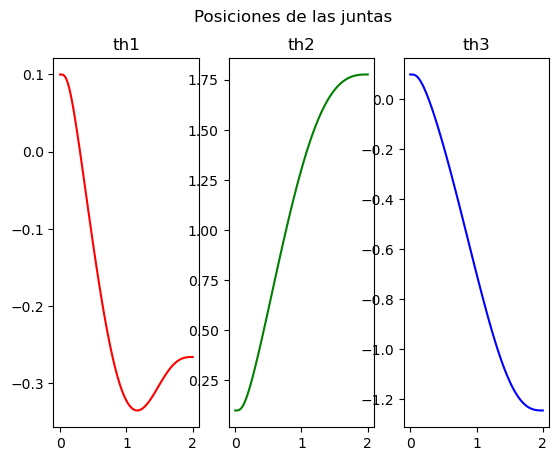

In [90]:
# Gráficas
fig, (th1_g, th2_g, th3_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Posiciones de las juntas")
th1_g.set_title("th1")
th2_g.set_title("th2")
th3_g.set_title("th3")
th1_g.plot(t_m.T, th_m[0, :].T, color="RED")
th2_g.plot(t_m.T, th_m[1, :].T, color="green")
th3_g.plot(t_m.T, th_m[2, :].T, color=(0,0,1))
plt.show()

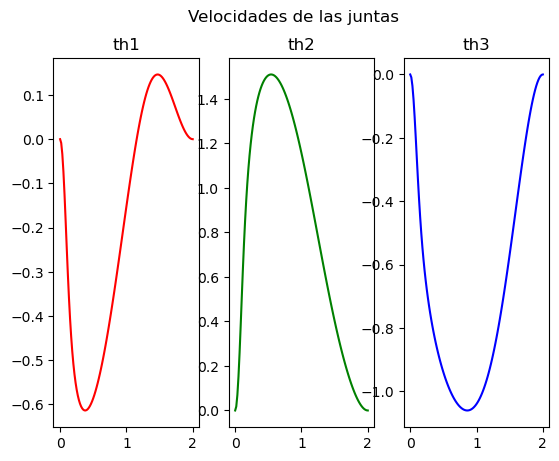

In [94]:
# Gráficas
fig, (th1_dot_g, th2_dot_g, th3_dot_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Velocidades de las juntas")
th1_dot_g.set_title("th1")
th2_dot_g.set_title("th2")
th3_dot_g.set_title("th3")
th1_dot_g.plot(t_m.T, th_dot_m[0, :].T, color="RED")
th2_dot_g.plot(t_m.T, th_dot_m[1, :].T, color="green")
th3_dot_g.plot(t_m.T, th_dot_m[2, :].T, color=(0,0,1))
plt.show()

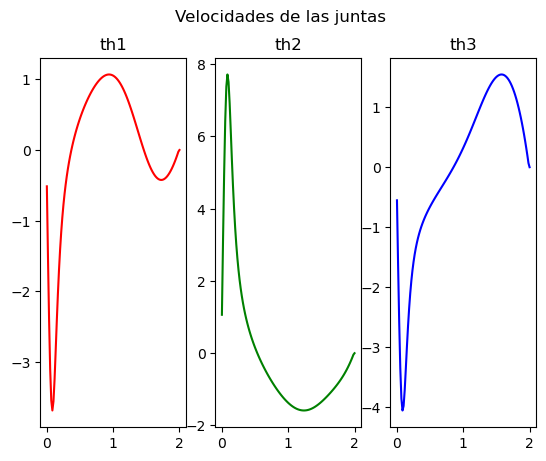

In [ ]:
# Gráficas
fig, (th1_dot_dot_g, th2_dot_dot_g, th3_dot_dot_g) = plt.subplots(nrows = 1, ncols = 3)
fig.suptitle("Aceleraciones de las juntas")
th1_dot_dot_g.set_title("th1")
th2_dot_dot_g.set_title("th2")
th3_dot_dot_g.set_title("th3")
th1_dot_dot_g.plot(t_m.T, th_dot_dot_m[0, :].T, color="RED")
th2_dot_dot_g.plot(t_m.T, th_dot_dot_m[1, :].T, color="green")
th3_dot_dot_g.plot(t_m.T, th_dot_dot_m[2, :].T, color=(0,0,1))
plt.show()